# Лабораторная работа 2: «Разработка сверточной нейронной сети с использованием PyTorch»

## Цели и задачи

**Цель работы** — разработать и обучить сверточную нейронную сеть для задачи классификации изображений на наборе данных CIFAR-10 с использованием фреймворка PyTorch.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 1. Загрузка и предобработка данных CIFAR-10

In [3]:
# Вычислим mean и std по RGB каналам для нормализации
temp_transform = transforms.Compose([
    transforms.ToTensor()
])

temp_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=temp_transform)
temp_trainloader = torch.utils.data.DataLoader(
    temp_trainset, batch_size=len(temp_trainset), shuffle=False)


data = next(iter(temp_trainloader))[0] # Берем только изображения
mean = data.mean(dim=(0, 2, 3))        # Среднее по каналам (batch, height, width)
std = data.std(dim=(0, 2, 3))          # STD по каналам (batch, height, width)
print(f"Mean: {mean.tolist()}")
print(f"Std:  {std.tolist()}")


norm_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:08<00:00, 19.7MB/s]
/home/tvblackman1/venvs/torch_env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Mean: [0.491400808095932, 0.48215898871421814, 0.44653093814849854]
Std:  [0.24703224003314972, 0.24348513782024384, 0.26158785820007324]


In [4]:
batch_size = 128

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=norm_transform)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=norm_transform)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

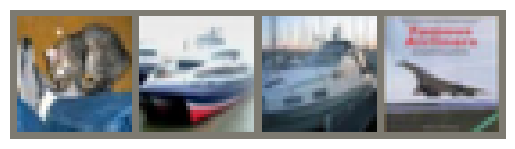

cat             ship            ship            plane          


In [5]:
def imshow_normalized(img, mean, std):
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)

imshow_normalized(torchvision.utils.make_grid(images[:4]), mean.tolist(), std.tolist())
print(' '.join(f'{classes[labels[j]]:15s}' for j in range(4)))

## 2. Реализация ResNet18

In [6]:
class BasicBlock(nn.Module):
    expansion = 1 # коэффициент расширения каналов (для ResNet50+)

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [28]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

model = ResNet18().to(device)

## 3. Функция потерь и оптимизатор

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [9]:
def calculate_test_loss_and_accuracy(model, testloader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(testloader)
    test_accuracy = 100 * correct / total

    return avg_test_loss, test_accuracy

## 4. Обучение модели

In [10]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

num_epochs = 50
best_accuracy = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(trainloader, desc=f'Epoch [{epoch+1}/{num_epochs}]')

    for i, data in enumerate(loop):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Обновление прогресс-бара
        loop.set_postfix(loss=loss.item())

    train_accuracy = 100 * correct / total
    test_loss, test_accuracy = calculate_test_loss_and_accuracy(model, testloader, criterion)

    train_losses.append(running_loss / len(trainloader))
    test_losses.append(test_loss)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    scheduler.step()


    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {running_loss/len(trainloader):.4f}, '
          f'Test Loss: {test_loss:.4f}, '
          f'Train Accuracy: {train_accuracy:.2f}%, '
          f'Test Accuracy: {test_accuracy:.2f}%')

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        torch.save(model.state_dict(), 'best_resnet18_cifar10.pth')

print(f'Best test accuracy: {best_accuracy:.2f}%')

Epoch [1/50]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 32.67it/s, loss=1.56]


Epoch [1/50], Train Loss: 1.8691, Test Loss: 1.5363, Train Accuracy: 33.29%, Test Accuracy: 42.85%


Epoch [2/50]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.40it/s, loss=1.16]


Epoch [2/50], Train Loss: 1.3365, Test Loss: 1.2468, Train Accuracy: 51.41%, Test Accuracy: 53.24%


Epoch [3/50]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.33it/s, loss=1.03]


...

Epoch [48/50], Train Loss: 0.0025, Test Loss: 0.4235, Train Accuracy: 100.00%, Test Accuracy: 87.82%


Epoch [49/50]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.27it/s, loss=0.00339]


Epoch [49/50], Train Loss: 0.0025, Test Loss: 0.4220, Train Accuracy: 100.00%, Test Accuracy: 87.83%


Epoch [50/50]: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.24it/s, loss=0.0019]


Epoch [50/50], Train Loss: 0.0025, Test Loss: 0.4217, Train Accuracy: 100.00%, Test Accuracy: 87.89%
Best test accuracy: 87.89%


## 5. Визуализация результатов

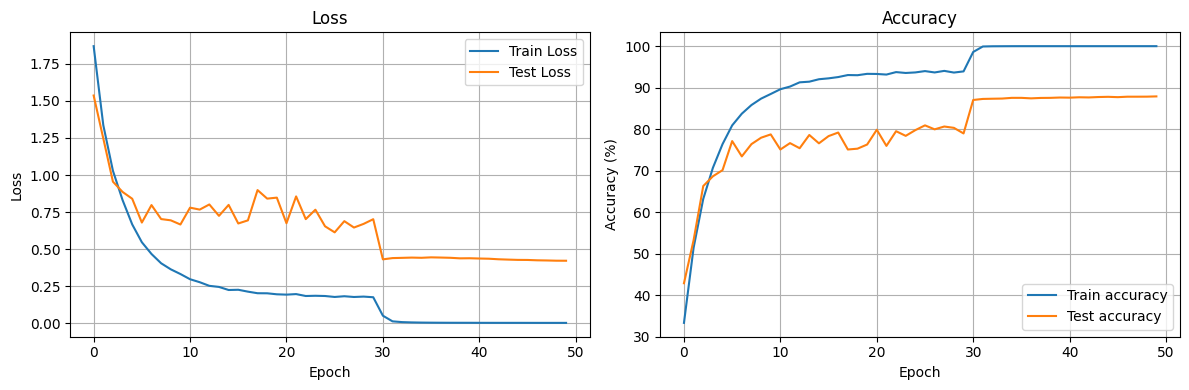

In [24]:
# Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train accuracy')
plt.plot(test_accuracies, label='Test accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
model.load_state_dict(torch.load('best_resnet18_cifar10.pth'))
final_test_loss, final_test_accuracy = calculate_test_loss_and_accuracy(model, testloader, criterion)
print(f'Test loss: {final_test_loss:.2f}')
print(f'Test accuracy: {final_test_accuracy:.2f}%')

Test loss: 0.42
Test accuracy: 87.89%


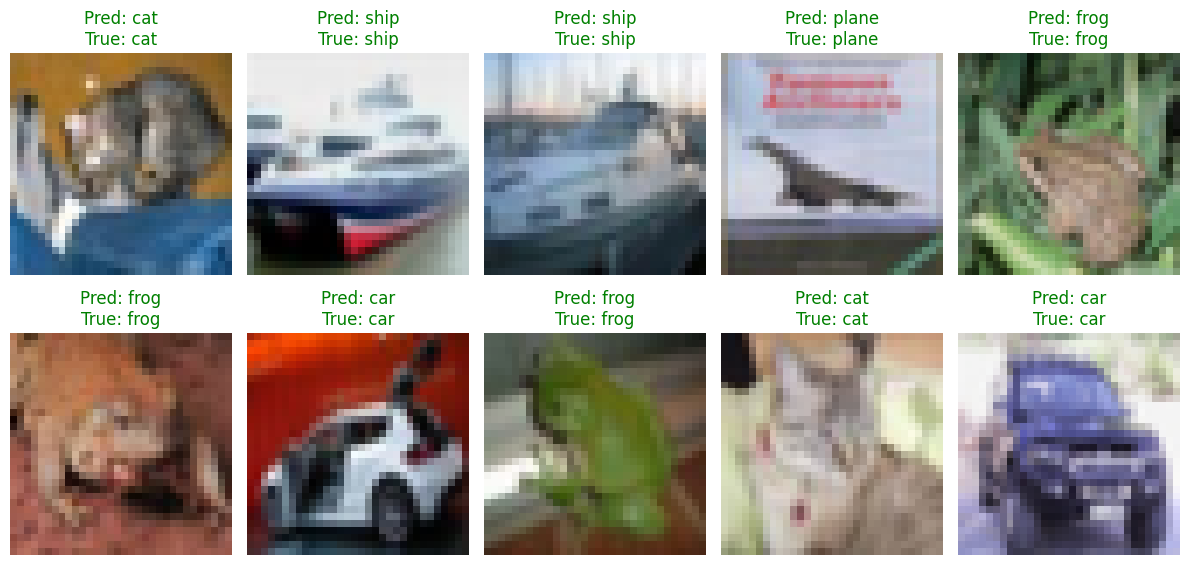

In [23]:
model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    ax = axes[i//5, i%5]

    img = images[i] * std.view(3, 1, 1) + \
          mean.view(3, 1, 1)
    img = torch.clamp(img, 0, 1)
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))

    is_correct = predicted[i] == labels[i]
    color = 'green' if is_correct else 'red'

    ax.set_title(
        f'Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}',
        color=color
    )

    ax.axis('off')

plt.tight_layout()
plt.show()

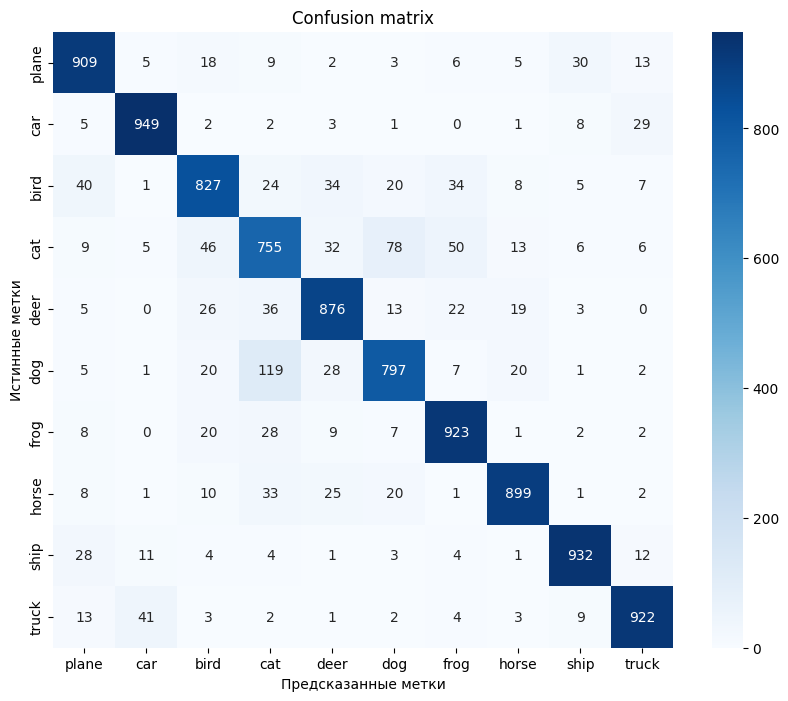

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion matrix')
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.show()